### Set Up

In [1]:
import torch
import torch.nn as nn
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from torch.utils.data import TensorDataset, DataLoader

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Load Dataset

In [3]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

In [4]:
housing_full = load_housing_data()

In [5]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Data Processing

In [6]:
housing_full = housing_full.drop("ocean_proximity", axis=1)

In [7]:
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_full)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','median_house_value']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](9,)","[ -118.49, 34.26, 29. ,..., 409. , 3.53,179700. ]"


In [8]:
X = imputer.transform(housing_full)
housing_full = pd.DataFrame(X, columns=housing_full.columns, index=housing_full.index)

In [9]:
train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)
train_set, val_set = train_test_split(train_set, test_size=0.2, random_state=42)
housing_full.shape, train_set.shape, val_set.shape, test_set.shape

((20640, 9), (13209, 9), (3303, 9), (4128, 9))

In [10]:
X_train, y_train = train_set.drop("median_house_value", axis=1), train_set["median_house_value"]
X_valid, y_valid = val_set.drop("median_house_value", axis=1), val_set["median_house_value"]
X_test, y_test = test_set.drop("median_house_value", axis=1), test_set["median_house_value"]

In [11]:
X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float64, device=device)
X_valid = torch.tensor(X_valid.to_numpy(), dtype=torch.float64, device=device)
X_test = torch.tensor(X_test.to_numpy(), dtype=torch.float64, device=device)

In [12]:
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)
y_valid = torch.tensor(y_valid.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)

In [13]:
X_train

tensor([[-1.2129e+02,  3.8710e+01,  3.2000e+01,  ...,  1.0270e+03,
          3.4300e+02,  3.5769e+00],
        [-1.2138e+02,  3.8640e+01,  1.9000e+01,  ...,  2.2560e+03,
          9.2600e+02,  2.1472e+00],
        [-1.2129e+02,  3.8900e+01,  4.5000e+01,  ...,  1.1040e+03,
          4.0700e+02,  3.1691e+00],
        ...,
        [-1.1714e+02,  3.2710e+01,  4.3000e+01,  ...,  8.5700e+02,
          2.0800e+02,  1.2841e+00],
        [-1.2226e+02,  3.7880e+01,  5.2000e+01,  ...,  1.7980e+03,
          7.6900e+02,  1.7250e+00],
        [-1.1750e+02,  3.4660e+01,  2.0000e+01,  ...,  4.8600e+02,
          1.9600e+02,  2.0184e+00]], device='cuda:0', dtype=torch.float64)

In [14]:
y_train

tensor([[103800.],
        [143400.],
        [108700.],
        ...,
        [ 72000.],
        [287500.],
        [ 84900.]], device='cuda:0', dtype=torch.float64)

In [15]:
X_train.device, y_train.device

(device(type='cuda', index=0), device(type='cuda', index=0))

In [16]:
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train- means) / stds
X_valid = (X_valid- means) / stds
X_test = (X_test- means) / stds

In [17]:
X_train

tensor([[-0.8667,  1.4490,  0.2663,  ..., -0.3487, -0.4120, -0.1475],
        [-0.9118,  1.4161, -0.7652,  ...,  0.7295,  1.1263, -0.8947],
        [-0.8667,  1.5382,  1.2979,  ..., -0.2811, -0.2431, -0.3606],
        ...,
        [ 1.2113, -1.3684,  1.1392,  ..., -0.4978, -0.7682, -1.3459],
        [-1.3525,  1.0592,  1.8533,  ...,  0.3277,  0.7121, -1.1154],
        [ 1.0311, -0.4528, -0.6859,  ..., -0.8233, -0.7998, -0.9621]],
       device='cuda:0', dtype=torch.float64)

In [18]:
ymeans = y_train.mean(dim=0, keepdims=True)
ystds = y_train.std(dim=0, keepdims=True)
y_train = (y_train- ymeans) / ystds
y_valid = (y_valid- ymeans) / ystds
y_test = (y_test- ymeans) / ystds

In [19]:
train_dataset = TensorDataset(X_train, y_train)
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, persistent_workers=True, num_workers=8, prefetch_factor=8)

### Model

In [20]:
torch.manual_seed(42)
n_features = X_train.shape[1] # there are 8 input features

#### Wide & Deep Network

In [21]:
learning_rate = 0.001
n_epochs = 100

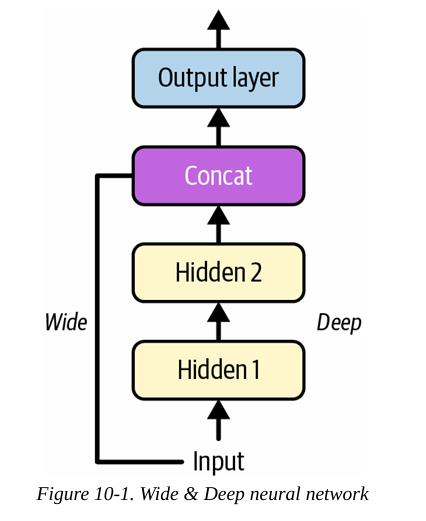

In [22]:
class WideAndDeep(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(nn.Linear(n_features, 50), nn.ReLU(), nn.Linear(50, 40), nn.ReLU(),)
        self.output_layer = nn.Linear(40 + n_features, 1)

    def forward(self, X):
        deep_output = self.deep_stack(X)
        wide_and_deep = torch.concat([X, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [23]:
torch.manual_seed(42)
model = WideAndDeep(n_features).to(device=device, dtype=torch.float64)
model

WideAndDeep(
  (deep_stack): Sequential(
    (0): Linear(in_features=8, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=40, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=48, out_features=1, bias=True)
)

In [24]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [25]:
def train(model, optimizer, criterion, train_loader, X_val, y_val, n_epochs):
    model.train()
    losses = []
    val_losses = []
    for epoch in range(n_epochs):
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(train_loader)
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}")
    return losses, val_losses

In [26]:
train_loss, val_loss = train(model, optimizer, mse, train_loader, X_valid, y_valid, n_epochs)

Epoch 1/100, Loss: 0.9831, Validation Loss: 0.9365946573207791
Epoch 2/100, Loss: 0.8594, Validation Loss: 0.830530209011131
Epoch 3/100, Loss: 0.7713, Validation Loss: 0.7504654235891478
Epoch 4/100, Loss: 0.7016, Validation Loss: 0.68867097600928
Epoch 5/100, Loss: 0.6498, Validation Loss: 0.6402118389686701
Epoch 6/100, Loss: 0.6099, Validation Loss: 0.6018316647311902
Epoch 7/100, Loss: 0.5778, Validation Loss: 0.5711259552779949
Epoch 8/100, Loss: 0.5517, Validation Loss: 0.5462459421485866
Epoch 9/100, Loss: 0.5317, Validation Loss: 0.5259197265058804
Epoch 10/100, Loss: 0.5146, Validation Loss: 0.5091819682389539
Epoch 11/100, Loss: 0.5000, Validation Loss: 0.49531902682890067
Epoch 12/100, Loss: 0.4901, Validation Loss: 0.48378179465498544
Epoch 13/100, Loss: 0.4812, Validation Loss: 0.47403711803610327
Epoch 14/100, Loss: 0.4737, Validation Loss: 0.4657999832643097
Epoch 15/100, Loss: 0.4655, Validation Loss: 0.45874671890898894
Epoch 16/100, Loss: 0.4615, Validation Loss: 0.4

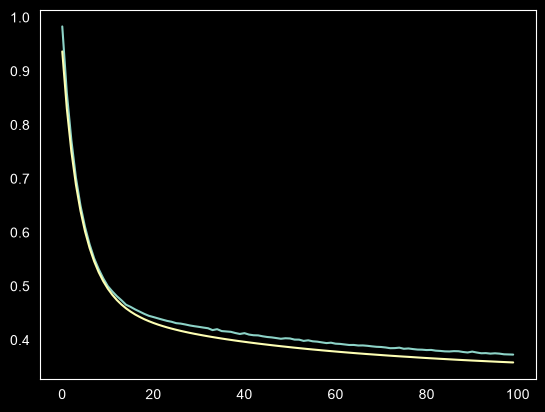

In [27]:
plt.plot(list(range(n_epochs)), train_loss)
plt.plot(list(range(n_epochs)), val_loss)
plt.grid()
plt.show()

In [28]:
with torch.no_grad():
    y_test_pred = model(X_test)
    loss_test = mse(y_test_pred, y_test)
loss_test

tensor(0.3853, device='cuda:0', dtype=torch.float64)

#### Multi Input Network

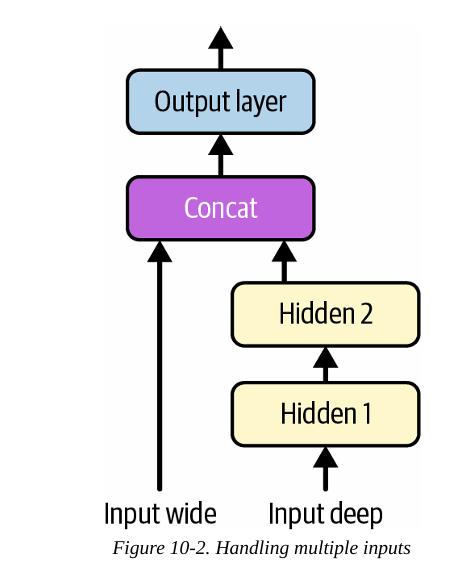

In [29]:
learning_rate = 0.001
n_epochs = 100

In [30]:
class MultipleInput(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(nn.Linear(n_features, 50), nn.ReLU(), nn.Linear(50, 40), nn.ReLU(),)
        self.output_layer = nn.Linear(45, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [31]:
torch.manual_seed(42)
model = MultipleInput(6).to(device=device, dtype=torch.float64)
model

MultipleInput(
  (deep_stack): Sequential(
    (0): Linear(in_features=6, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=40, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=45, out_features=1, bias=True)
)

In [32]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [33]:
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=batch_size, shuffle=True)

val_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
val_loader_wd = DataLoader(val_data_wd, batch_size=batch_size, shuffle=True)

test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=batch_size, shuffle=True)

In [34]:
def train(model, optimizer, criterion, train_loader, X_val, y_val, n_epochs):
    model.train()
    losses = []
    val_losses = []
    for epoch in range(n_epochs):
        total_loss = 0.
        for X_batch_wide, X_batch_deep, y_batch in train_loader_wd:
            X_batch_wide = X_batch_wide.to(device)
            X_batch_deep = X_batch_deep.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_wide=X_batch_wide, X_deep=X_batch_deep)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(train_loader)
        x_val1, x_val2, y_val = next(iter(val_loader_wd))
        y_val_pred = model(x_val1, x_val2)
        val_loss = criterion(y_val_pred, y_val)
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}")
    return losses, val_losses

In [35]:
train_loss, val_loss = train(model, optimizer, mse, train_loader, X_valid, y_valid, n_epochs)

Epoch 1/100, Loss: 1.1173, Validation Loss: 1.1281188497314
Epoch 2/100, Loss: 1.0448, Validation Loss: 1.0491028254200854
Epoch 3/100, Loss: 0.9917, Validation Loss: 0.9835674509814806
Epoch 4/100, Loss: 0.9509, Validation Loss: 0.9594994765046266
Epoch 5/100, Loss: 0.9160, Validation Loss: 0.8777709204441375
Epoch 6/100, Loss: 0.8845, Validation Loss: 0.9052074310987114
Epoch 7/100, Loss: 0.8584, Validation Loss: 0.9608759384496915
Epoch 8/100, Loss: 0.8353, Validation Loss: 1.0017584311864898
Epoch 9/100, Loss: 0.8118, Validation Loss: 0.8239612779586647
Epoch 10/100, Loss: 0.7917, Validation Loss: 0.7916037281245774
Epoch 11/100, Loss: 0.7723, Validation Loss: 0.6396567944573727
Epoch 12/100, Loss: 0.7497, Validation Loss: 0.8149591367814094
Epoch 13/100, Loss: 0.7316, Validation Loss: 0.8405908496528899
Epoch 14/100, Loss: 0.7133, Validation Loss: 0.7424399148832654
Epoch 15/100, Loss: 0.6924, Validation Loss: 0.6983500894076247
Epoch 16/100, Loss: 0.6747, Validation Loss: 0.63825

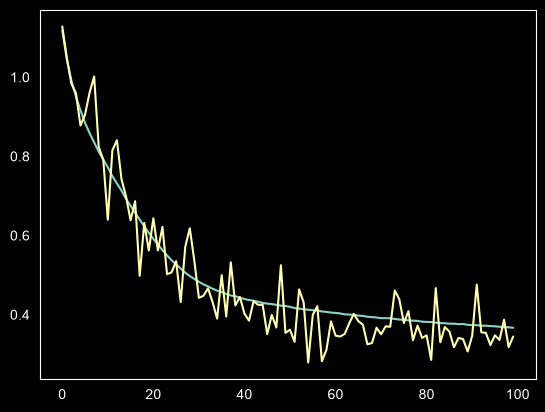

In [36]:
plt.plot(list(range(n_epochs)), train_loss)
plt.plot(list(range(n_epochs)), val_loss)
plt.grid()
plt.show()

In [37]:
with torch.no_grad():
    x_t, x_t1, y_t = next(iter(test_loader_wd))
    y_test_pred = model(x_t, x_t1)
    loss_test = mse(y_test_pred, y_t)
loss_test

tensor(0.4418, device='cuda:0', dtype=torch.float64)

#### Multiple Output Network

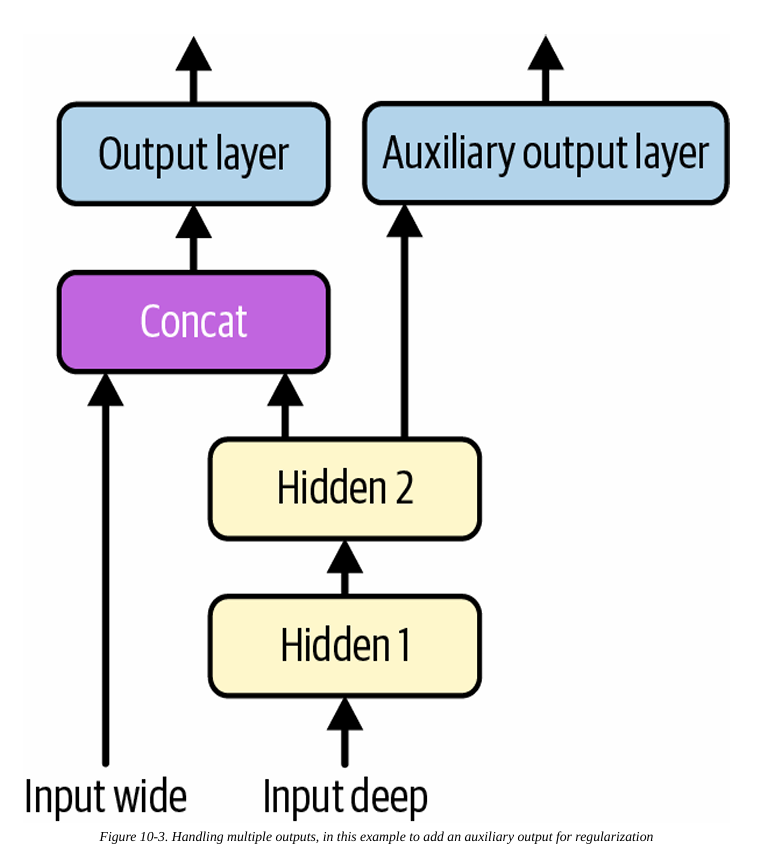

In [38]:
learning_rate = 0.001
n_epochs = 100

In [39]:
class MultipleOutput(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(nn.Linear(n_features, 50), nn.ReLU(), nn.Linear(50, 40), nn.ReLU(),)
        self.output_layer = nn.Linear(45, 1)
        self.aux_output_layer = nn.Linear(40, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        main_output = self.output_layer(wide_and_deep)
        aux_output = self.aux_output_layer(deep_output)
        return main_output, aux_output

In [40]:
torch.manual_seed(42)
model = MultipleOutput(6).to(device=device, dtype=torch.float64)
model

MultipleOutput(
  (deep_stack): Sequential(
    (0): Linear(in_features=6, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=40, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=45, out_features=1, bias=True)
  (aux_output_layer): Linear(in_features=40, out_features=1, bias=True)
)

In [41]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [42]:
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=batch_size, shuffle=True)

val_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
val_loader_wd = DataLoader(val_data_wd, batch_size=batch_size, shuffle=True)

test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=batch_size, shuffle=True)

In [43]:
def train_multi_output(model, optimizer, criterion, train_loader, X_val, y_val, n_epochs):
    model.train()
    losses = []
    val_losses = []
    for epoch in range(n_epochs):
        total_loss = 0.
        for X_batch_wide, X_batch_deep, y_batch in train_loader_wd:
            X_batch_wide = X_batch_wide.to(device)
            X_batch_deep = X_batch_deep.to(device)
            y_batch = y_batch.to(device)
            y_pred, y_aux_pred = model(X_batch_wide, X_batch_deep)
            train_loss = criterion(y_pred, y_batch)
            aux_loss = criterion(y_aux_pred, y_batch)
            loss = 0.8*train_loss + 0.2*aux_loss
            total_loss += loss.item()
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(train_loader)
        x_val1, x_val2, y_val = next(iter(val_loader_wd))
        y_val_pred, _ = model(x_val1, x_val2)
        val_loss = criterion(y_val_pred, y_val)
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}")
    return losses, val_losses

In [44]:
train_loss, val_loss = train_multi_output(model, optimizer, mse, train_loader, X_valid, y_valid, n_epochs)

Epoch 1/100, Loss: 1.0917, Validation Loss: 1.1690721356471026
Epoch 2/100, Loss: 1.0319, Validation Loss: 1.020379141066019
Epoch 3/100, Loss: 0.9899, Validation Loss: 1.047823840348259
Epoch 4/100, Loss: 0.9534, Validation Loss: 0.9564339032725898
Epoch 5/100, Loss: 0.9267, Validation Loss: 0.8375202375904505
Epoch 6/100, Loss: 0.9000, Validation Loss: 0.9458681722934604
Epoch 7/100, Loss: 0.8792, Validation Loss: 0.8506166597603741
Epoch 8/100, Loss: 0.8589, Validation Loss: 0.9116293837036895
Epoch 9/100, Loss: 0.8390, Validation Loss: 0.8302784693182239
Epoch 10/100, Loss: 0.8226, Validation Loss: 0.8104650997926037
Epoch 11/100, Loss: 0.8045, Validation Loss: 0.7121335628972462
Epoch 12/100, Loss: 0.7872, Validation Loss: 0.7415140924948707
Epoch 13/100, Loss: 0.7696, Validation Loss: 0.7552220654453633
Epoch 14/100, Loss: 0.7542, Validation Loss: 0.7966906662437737
Epoch 15/100, Loss: 0.7384, Validation Loss: 0.6210190008559919
Epoch 16/100, Loss: 0.7229, Validation Loss: 0.6920

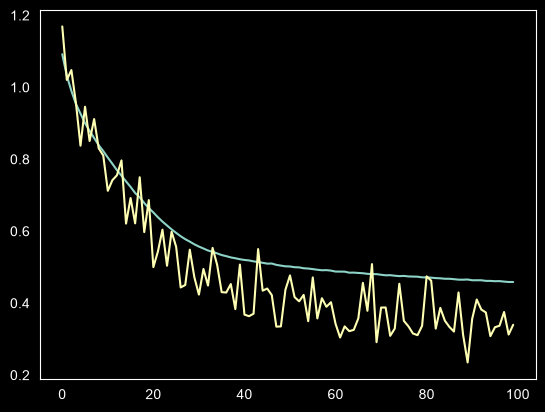

In [45]:
plt.plot(list(range(n_epochs)), train_loss)
plt.plot(list(range(n_epochs)), val_loss)
plt.grid()
plt.show()

In [46]:
with torch.no_grad():
    x_t, x_t1, y_t = next(iter(test_loader_wd))
    y_test_pred, _ = model(x_t, x_t1)
    loss_test = mse(y_test_pred, y_t)
loss_test

tensor(0.3277, device='cuda:0', dtype=torch.float64)